In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os

sc.settings.verbosity = 3
sc.settings.figdir = 'outputs/'
os.makedirs('outputs', exist_ok=True)

# Load preprocessed data from Section 1
adata = sc.read_h5ad(
    r'C:\Users\HP\Downloads\scRNA-seq-repo-v2\scRNA-seq-repo\01_preprocessing\notebooks\outputs\preprocessed_adata.h5ad'
)

print(adata)

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'


computing PCA
    with n_comps=50
    finished (0:00:02)


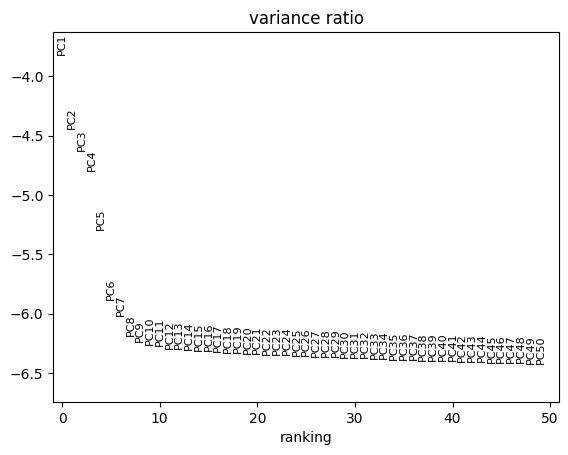

PCA complete!
PCA embedding shape: (2638, 50)


In [3]:
# Run PCA
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)

# Elbow plot to choose number of PCs
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='_elbow.png')

print("PCA complete!")
print(f"PCA embedding shape: {adata.obsm['X_pca'].shape}")

computing neighbors
    using 'X_pca' with n_pcs = 10


C:\Users\HP\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:45)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)


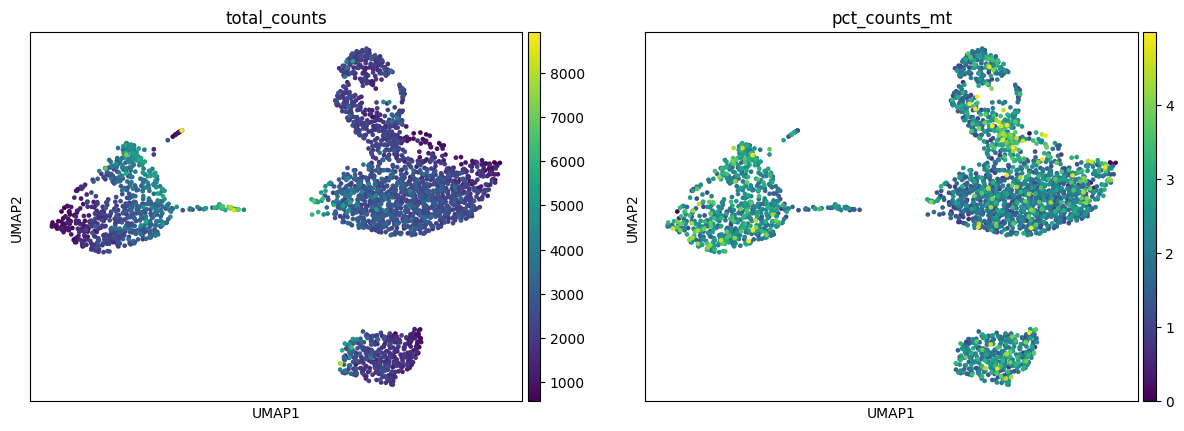

UMAP complete!


In [4]:
# Build neighborhood graph using top 10 PCs
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)

# Compute UMAP
sc.tl.umap(adata)

# Visualize UMAP
sc.pl.umap(
    adata,
    color=['total_counts', 'pct_counts_mt'],
    save='_qc.png'
)

print("UMAP complete!")

running Leiden clustering


C:\Users\HP\AppData\Local\Temp\ipykernel_6724\3664548045.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
Number of clusters: 9


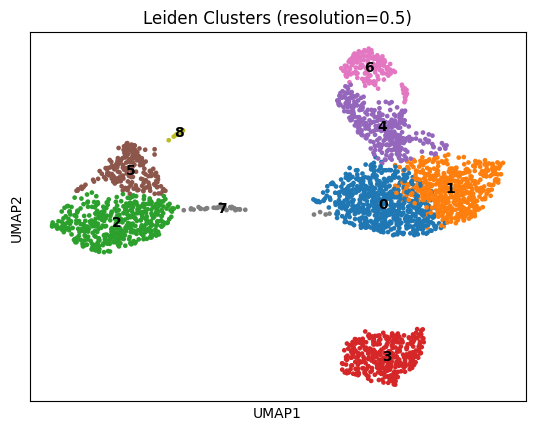

In [5]:
# Run Leiden clustering
sc.tl.leiden(
    adata,
    resolution=0.5,
    random_state=42,
    key_added='leiden'
)

print(f"Number of clusters: {adata.obs['leiden'].nunique()}")

# Visualize clusters on UMAP
sc.pl.umap(
    adata,
    color=['leiden'],
    legend_loc='on data',
    legend_fontsize=10,
    title='Leiden Clusters (resolution=0.5)',
    save='_clusters.png'
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:12)


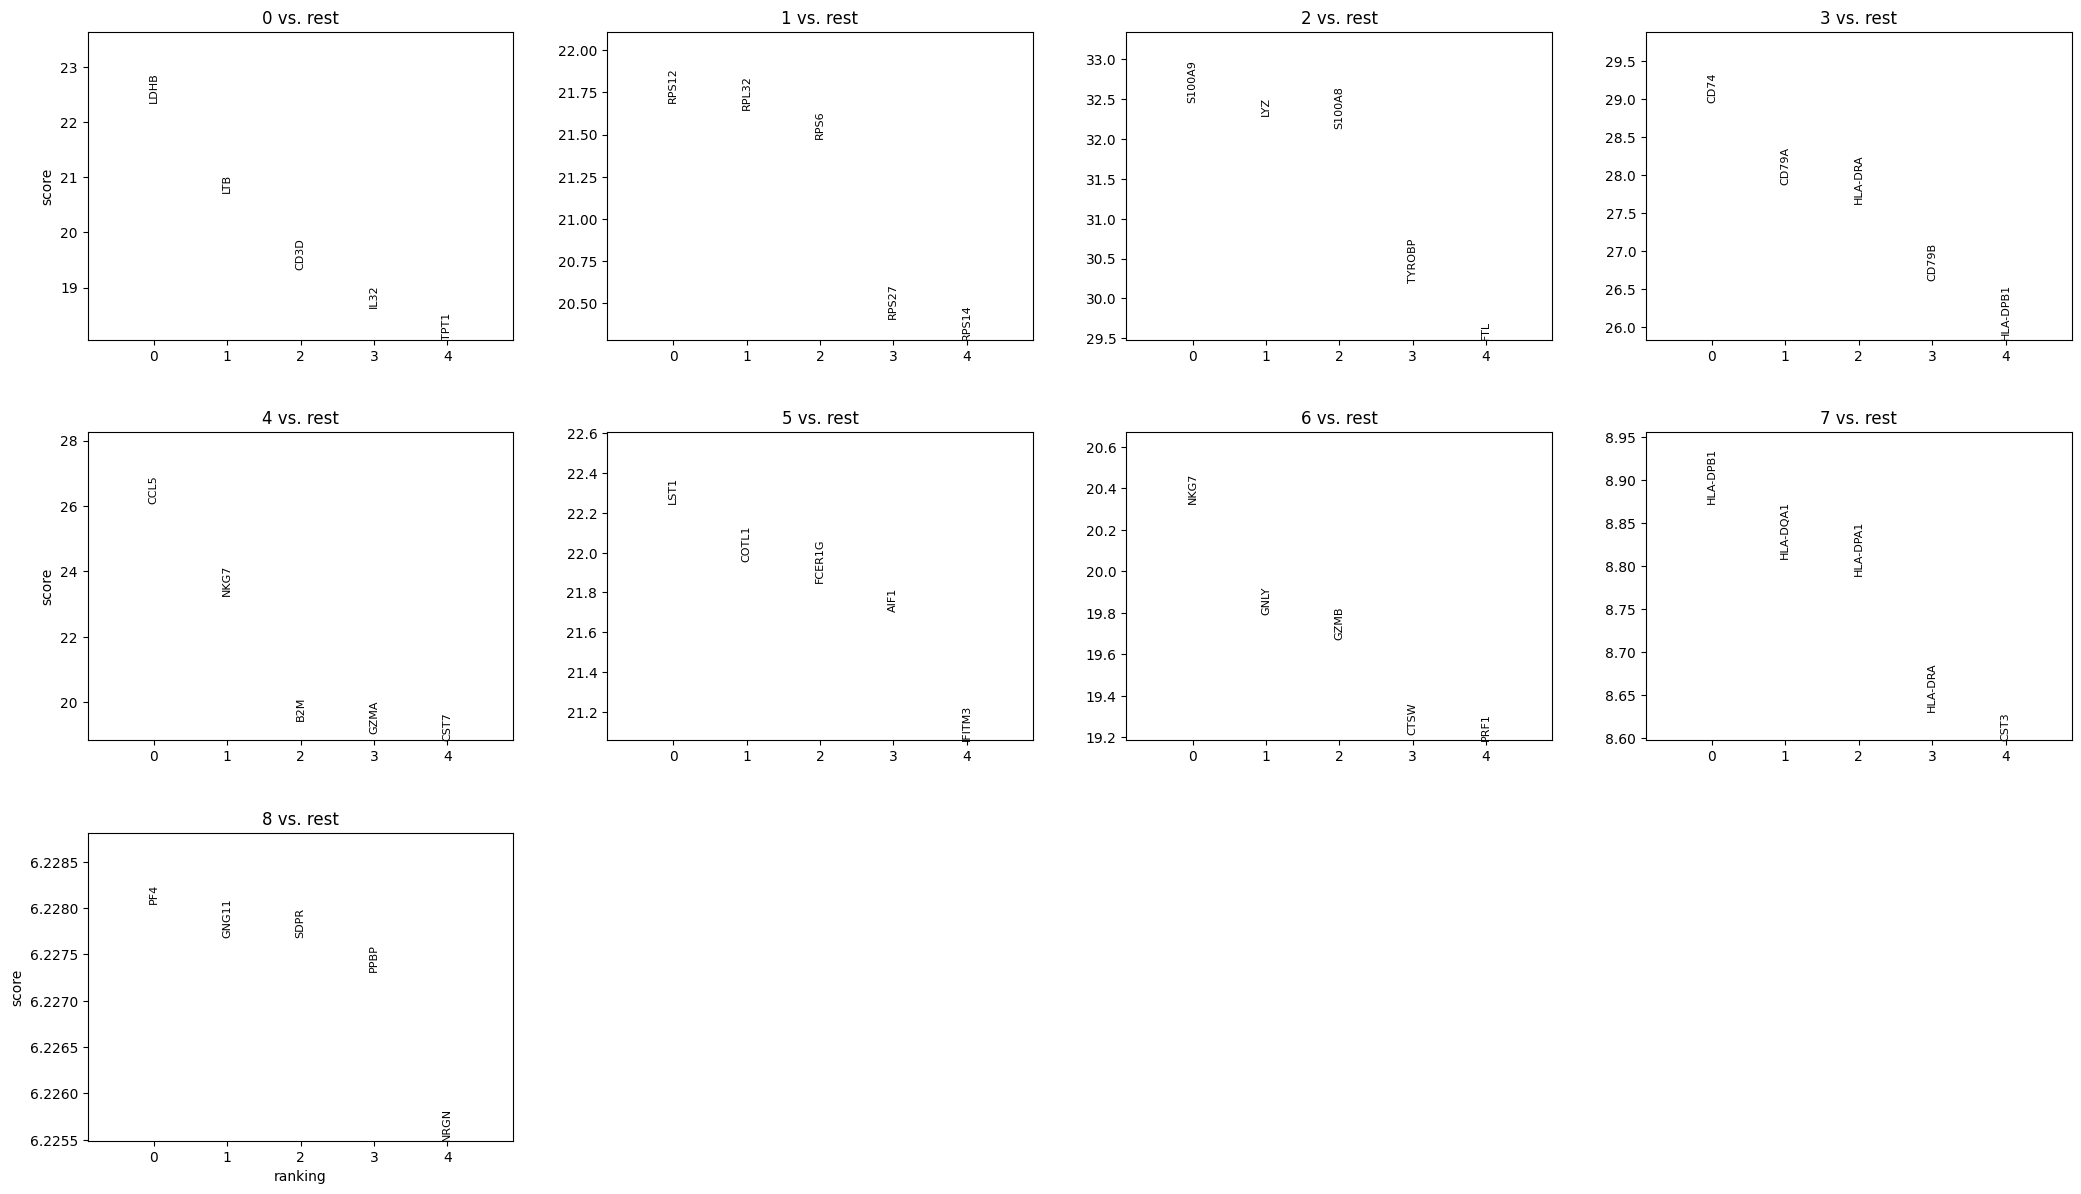

Marker genes saved!
      0      1       2         3     4       5     6         7      8
0  LDHB  RPS12  S100A9      CD74  CCL5    LST1  NKG7  HLA-DPB1    PF4
1   LTB  RPL32     LYZ     CD79A  NKG7   COTL1  GNLY  HLA-DQA1  GNG11
2  CD3D   RPS6  S100A8   HLA-DRA   B2M  FCER1G  GZMB  HLA-DPA1   SDPR
3  IL32  RPS27  TYROBP     CD79B  GZMA    AIF1  CTSW   HLA-DRA   PPBP
4  TPT1  RPS14     FTL  HLA-DPB1  CST7  IFITM3  PRF1      CST3   NRGN


In [6]:
# Find marker genes per cluster using Wilcoxon test
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',
    method='wilcoxon',
    key_added='rank_genes_groups'
)

# Visualize top 5 markers per cluster
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False, save='_markers.png')

# Export to CSV
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
marker_df = pd.DataFrame({
    group: result['names'][group][:20] for group in groups
})
marker_df.to_csv('outputs/marker_genes.csv', index=False)

print("Marker genes saved!")
print(marker_df.head())

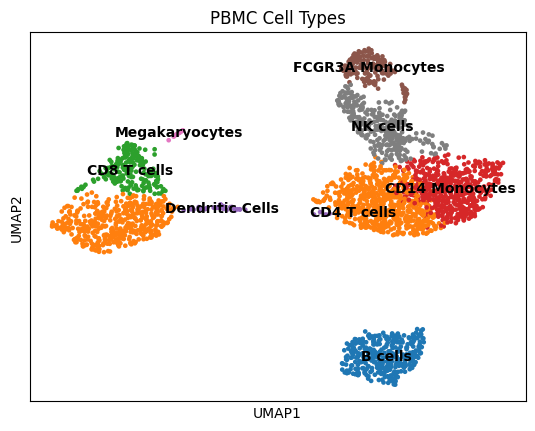

✅ Section 2 Complete!
cell_type
CD4 T cells         1064
CD14 Monocytes       508
B cells              344
NK cells             313
CD8 T cells          203
FCGR3A Monocytes     155
Dendritic Cells       38
Megakaryocytes        13
Name: count, dtype: int64


In [7]:
# Annotate cell types based on marker genes
cluster_to_celltype = {
    '0': 'CD4 T cells',
    '1': 'CD14 Monocytes',
    '2': 'CD4 T cells',
    '3': 'B cells',
    '4': 'NK cells',
    '5': 'CD8 T cells',
    '6': 'FCGR3A Monocytes',
    '7': 'Dendritic Cells',
    '8': 'Megakaryocytes'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype)

# Final annotated UMAP
sc.pl.umap(
    adata,
    color=['cell_type'],
    legend_loc='on data',
    title='PBMC Cell Types',
    save='_celltypes.png'
)

# Save final AnnData
adata.write('outputs/clustered_adata.h5ad')
print("✅ Section 2 Complete!")
print(adata.obs['cell_type'].value_counts())